# ❤️ PFA — Maladie Coronarienne à 10 ans (Framingham)
### Pipeline ML complet · Version corrigée & améliorée
---

## 1 · Importations

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
from imblearn.over_sampling import SMOTE

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost non installé — pip install xgboost")

RANDOM_STATE = 42
print("✓ Importations OK")

✓ Importations OK


In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


## 2 · Chargement & Exploration

Shape : (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0



Valeurs manquantes par colonne :


glucose       388
education     105
BPMeds         53
totChol        50
cigsPerDay     29
BMI            19
heartRate       1
dtype: int64

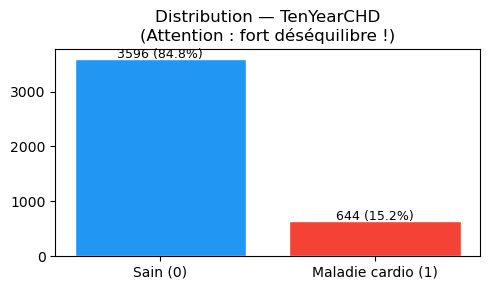

⚠️  Seulement ~15% de cas positifs → SMOTE obligatoire !


In [3]:
df = pd.read_csv('framingham.csv', na_values=['NA', ''])
print(f"Shape : {df.shape}")
display(df.head())
print("\nValeurs manquantes par colonne :")
display(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

# ⚠️ Déséquilibre important — critique pour Framingham
fig, ax = plt.subplots(figsize=(5, 3))
counts = df['TenYearCHD'].value_counts()
bars = ax.bar(['Sain (0)', 'Maladie cardio (1)'], counts.values, color=['#2196F3','#F44336'], edgecolor='white')
ax.set_title('Distribution — TenYearCHD\n(Attention : fort déséquilibre !)')
for b in bars:
    ax.annotate(f'{int(b.get_height())} ({b.get_height()/len(df)*100:.1f}%)',
                (b.get_x()+b.get_width()/2, b.get_height()+10), ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print("⚠️  Seulement ~15% de cas positifs → SMOTE obligatoire !")

## 3 · Prétraitement

In [4]:
# --- 3.1 Imputation par la médiane ---
imputer = SimpleImputer(strategy='median')
X_raw = df.drop('TenYearCHD', axis=1)
y_raw = df['TenYearCHD']
df_imp = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)
df_imp['TenYearCHD'] = y_raw.values
print(f"Valeurs manquantes après imputation : {df_imp.isnull().sum().sum()}")

# --- 3.2 Séparation ---
X = df_imp.drop('TenYearCHD', axis=1)
y = df_imp['TenYearCHD'].astype(int)
feature_names = X.columns.tolist()

# --- 3.3 Split stratifié (CORRIGÉ) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")
print(f"Proportion cible train : {y_train.mean():.3f} | test : {y_test.mean():.3f}")

# --- 3.4 Standardisation ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# --- 3.5 SMOTE (CRITIQUE pour Framingham — 15% de positifs) ---
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)
print(f"\nAprès SMOTE → Total: {len(y_train_bal)} | Classe 0: {(y_train_bal==0).sum()} | Classe 1: {(y_train_bal==1).sum()}")

Valeurs manquantes après imputation : 0
Train : 3392 | Test : 848
Proportion cible train : 0.152 | test : 0.152

Après SMOTE → Total: 5754 | Classe 0: 2877 | Classe 1: 2877


## 4 · Entraînement des Modèles

In [5]:
models = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Arbre de Décision":     DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest":         RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM":                   SVC(probability=True, random_state=RANDOM_STATE),
    "Gradient Boosting":     GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}
if HAS_XGB:
    models["XGBoost"] = XGBClassifier(n_estimators=200, use_label_encoder=False,
                                       eval_metric='logloss', random_state=RANDOM_STATE)

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred    = model.predict(X_test_sc)
    y_proba   = model.predict_proba(X_test_sc)[:, 1]
    cv_scores = cross_val_score(model, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
    results[name] = {
        'Accuracy':      accuracy_score(y_test, y_pred),
        'Precision':     precision_score(y_test, y_pred, zero_division=0),
        'Recall':        recall_score(y_test, y_pred),
        'F1-score':      f1_score(y_test, y_pred),
        'AUC-ROC':       roc_auc_score(y_test, y_proba),
        'CV-AUC (mean)': cv_scores.mean(),
        'CV-AUC (std)':  cv_scores.std(),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        '_model': model, '_y_proba': y_proba,
    }
    print(f"  {name:<25} Acc={results[name]['Accuracy']:.3f} | F1={results[name]['F1-score']:.3f} | AUC={results[name]['AUC-ROC']:.3f} | CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}")

  Régression Logistique     Acc=0.667 | F1=0.356 | AUC=0.696 | CV=0.745±0.018
  Arbre de Décision         Acc=0.669 | F1=0.339 | AUC=0.659 | CV=0.765±0.011
  Random Forest             Acc=0.794 | F1=0.215 | AUC=0.632 | CV=0.966±0.005
  SVM                       Acc=0.677 | F1=0.315 | AUC=0.653 | CV=0.810±0.010
  Gradient Boosting         Acc=0.778 | F1=0.230 | AUC=0.635 | CV=0.933±0.008
  XGBoost                   Acc=0.788 | F1=0.167 | AUC=0.574 | CV=0.957±0.006


## 5 · Évaluation & Visualisations

In [6]:
metrics_df = pd.DataFrame({k: {m: v for m, v in vv.items()
                                if not m.startswith('_') and m != 'Confusion Matrix'}
                           for k, vv in results.items()}).T
display(metrics_df.style.highlight_max(axis=0, color='#d4f0c0').format("{:.4f}"))
best_model_name = metrics_df['AUC-ROC'].idxmax()
print(f"\n Meilleur modèle : {best_model_name}")

,Accuracy,Precision,Recall,F1-score,AUC-ROC,CV-AUC (mean),CV-AUC (std)
Régression Logistique,0.6675,0.2524,0.6047,0.3562,0.6962,0.7446,0.0183
Arbre de Décision,0.6686,0.2432,0.5581,0.3388,0.6587,0.7653,0.0107
Random Forest,0.7936,0.2553,0.1860,0.2152,0.6315,0.9658,0.0049
SVM,0.6769,0.2325,0.4884,0.3150,0.6529,0.8096,0.0095
Gradient Boosting,0.7783,0.2435,0.2171,0.2295,0.6348,0.9328,0.0077
XGBoost,0.7877,0.2069,0.1395,0.1667,0.5743,0.9573,0.0057



 Meilleur modèle : Régression Logistique


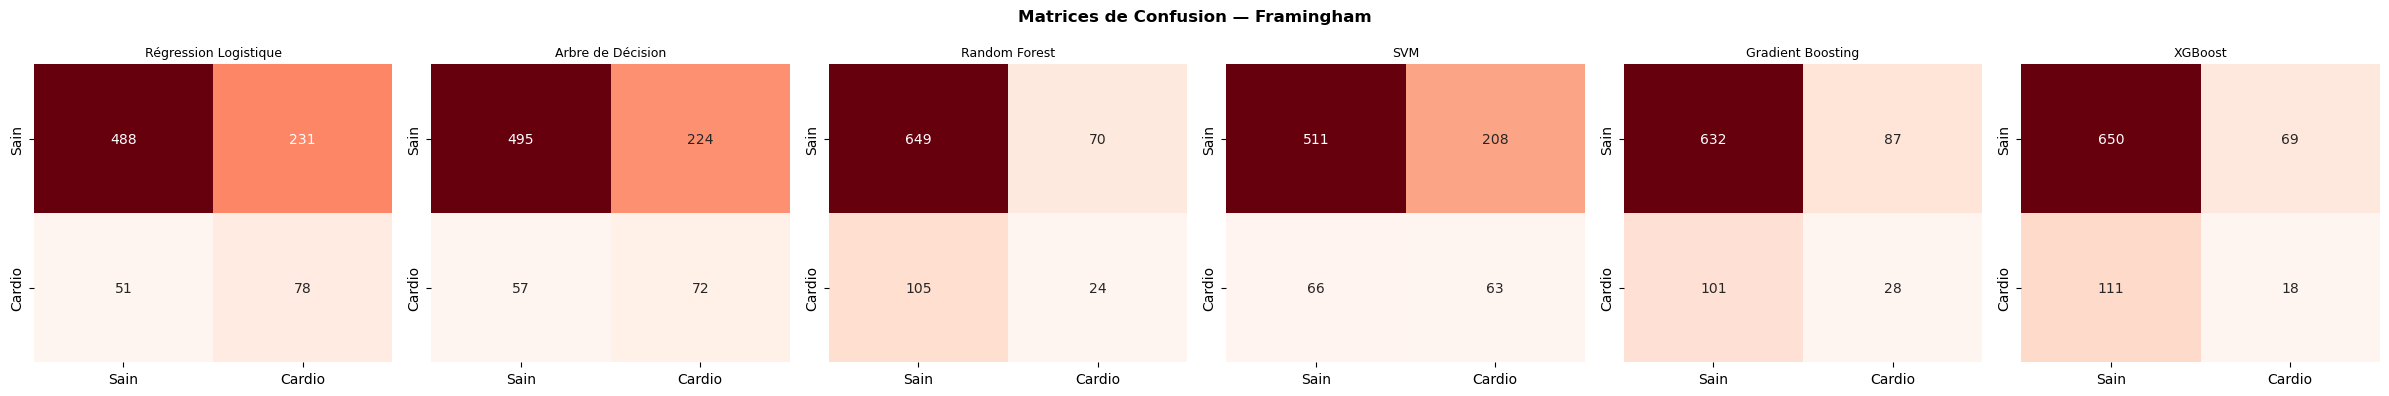

In [7]:
n = len(models)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for i, (name, res) in enumerate(results.items()):
    sns.heatmap(res['Confusion Matrix'], annot=True, fmt='d', ax=axes[i], cmap='Reds',
                cbar=False, xticklabels=['Sain','Cardio'], yticklabels=['Sain','Cardio'])
    axes[i].set_title(name, fontsize=9)
plt.suptitle('Matrices de Confusion — Framingham', fontweight='bold')
plt.tight_layout(); plt.show()

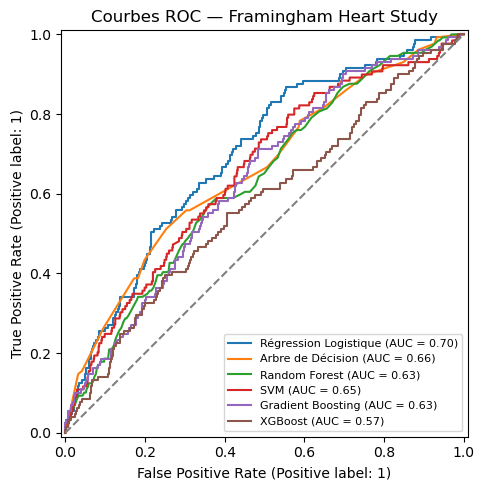

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res['_y_proba'], name=name, ax=ax)
ax.plot([0,1],[0,1],'--', color='gray')
ax.set_title('Courbes ROC — Framingham Heart Study')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

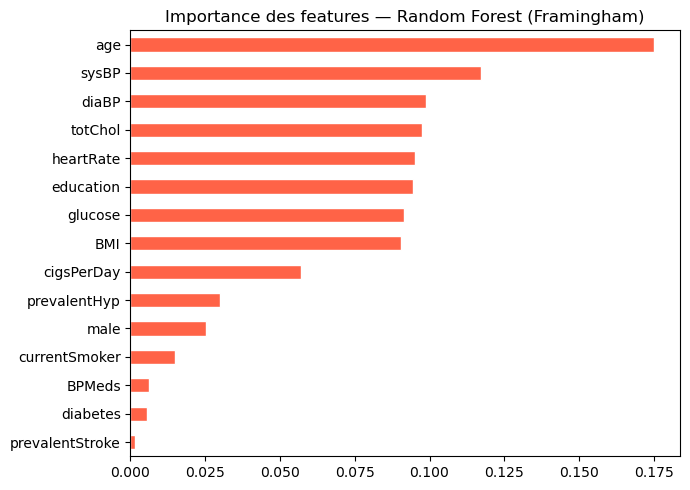

In [9]:
rf = results['Random Forest']['_model']
feat_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
feat_imp.plot.barh(ax=ax, color='tomato', edgecolor='white')
ax.set_title('Importance des features — Random Forest (Framingham)')
plt.tight_layout(); plt.show()

## 6 · Sauvegarde

In [10]:
best_model = results[best_model_name]['_model']
joblib.dump(best_model, 'model_framingham.pkl')
joblib.dump(scaler,     'scaler_framingham.pkl')
joblib.dump(imputer,    'imputer_framingham.pkl')
print(f"✓ Modèle '{best_model_name}' sauvegardé → model_framingham.pkl")

y_pred_best = best_model.predict(X_test_sc)
print(classification_report(y_test, y_pred_best, target_names=['Sain','Maladie cardio']))

✓ Modèle 'Régression Logistique' sauvegardé → model_framingham.pkl
                precision    recall  f1-score   support

          Sain       0.91      0.68      0.78       719
Maladie cardio       0.25      0.60      0.36       129

      accuracy                           0.67       848
     macro avg       0.58      0.64      0.57       848
  weighted avg       0.81      0.67      0.71       848

